In [1]:
import sys
import h5py
import numpy as np

# from cartopy import crs as ccrs
# from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

## Loading DATA

In [2]:
# parameters 
PR               = 50
level_index      = 5
file_path        = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF"


# define variables
lat              = np.linspace(-90, 90, 64)
lat_cond         = np.where((lat>=-15)&(lat<=15))[0]
var              = {}
var_list         = {'p','prec','u','v'}
for index, var_i in enumerate(var_list):
    with h5py.File(f"{file_path}/PR{PR}/{var_i}/PR{PR}_500_20000day_6hourly_{var_i}.dat") as f:
        if var_i == 'prec':
            var[f"{var_i}"] = f[var_i][:, :,:]*86400
        else:
            var[f"{var_i}"] = f[var_i][:, level_index, :]


## Wheeler and Kiladis (1999) Calculation



### Defining function

In [6]:
import warnings
# del FFT2D
def FFT2D(data,dim_time,dim_lon): 
    # input data should have dimension of [time X lon] (even only)
    # dim_time = the dimension of time
    # dim_lon  = the dimension of lon

    if ((dim_time % 2) != 0) or ((dim_lon % 2) != 0):
       print("input dimension is not even")
    else:
       print("pass dimension check")
    C_k = np.zeros((dim_time,int(dim_lon/2))) 
    S_k = np.zeros((dim_time,int(dim_lon/2)))
    
    
    for i in range(dim_time):
        fourier_coeffs           = np.fft.fft(data[i,:])
        C_k[i,1:]                = np.real(fourier_coeffs[1:int(dim_lon/2)]*2)/(dim_lon)
        S_k[i,1:]                = np.imag(fourier_coeffs[1:int(dim_lon/2)]*2)/(dim_lon)

    A_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    B_kw = np.zeros((int(dim_time/2),int(dim_lon/2)))
    a_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    b_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    fourier_coeffs_kw = np.zeros((2,C_k.shape[0],C_k.shape[1])) # first dimension: cos and sin, second dimension: frequency, third dimension: wave number
    
    for i in range(int(dim_lon/2)):
        fourier_coeffs           = np.fft.fft(C_k[:,i])
        fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time
        A_kw[:,i]                = np.real(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        B_kw[:,i]                = np.imag(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        fourier_coeffs           = np.fft.fft(S_k[:,i])
        a_kw[:,i]                = np.real(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        b_kw[:,i]                = np.imag(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)

    return A_kw, B_kw, a_kw, b_kw


# def FFT2D_ifft(A_kw, B_kw, a_kw, b_kw, direction="all"): 
#     if direction=="west":
#         sign = 1
#     elif direction=='east':
#         sign = -1
#     else: 
#         sign = 1
        
#     dim_time       = (A_kw.shape[0])*2
#     dim_lon        = (A_kw.shape[1])*2
#     C_k            = np.zeros((dim_time,A_kw.shape[1] ))
#     S_k            = np.zeros((dim_time,A_kw.shape[1] ))
#     data           = np.zeros((dim_time,dim_lon))
    
#     for k in range(A_kw.shape[1]):
#         fourier_coefficients                    = np.zeros((dim_time,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[0],]   = A_kw[:,k]+sign*1j*B_kw[:,k]
#         fourier_coefficients[A_kw.shape[0]+1:,] = (A_kw[1:,k]-sign*1j*B_kw[1:,k])[::-1]
#         fourier_coefficients[A_kw.shape[0]:A_kw.shape[0]+1,] =  A_kw[-1,k]-sign*1j*B_kw[-1,k]       
        
#         C_k[:,k]                                = np.fft.ifft(fourier_coefficients/2*dim_time)

        
#         fourier_coefficients                    = np.zeros((dim_time,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[0],]   = a_kw[:,k]+1j*b_kw[:,k]
#         fourier_coefficients[A_kw.shape[0]+1:,] = (a_kw[1:,k]-1j*b_kw[1:,k])[::-1]
#         fourier_coefficients[A_kw.shape[0]:A_kw.shape[0]+1,] =  a_kw[-1,k]-1j*b_kw[-1,k]      
#         S_k[:,k]                                = np.fft.ifft(fourier_coefficients/2*dim_time)

#     for t in range(dim_time):
#         fourier_coefficients                    = np.zeros((dim_lon,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[1],]   = C_k[t,:]+sign*1j*S_k[t,:]
#         fourier_coefficients[A_kw.shape[1]+1:,] = (C_k[t,1:]-sign*1j*S_k[t,1:])[::-1]
#         fourier_coefficients[A_kw.shape[1]:A_kw.shape[1]+1,] =  C_k[t,-1]-sign*1j*S_k[t,-1]       
#         data[t,:]                               = np.fft.ifft(fourier_coefficients/2*dim_lon)

    
#     return C_k, S_k, data

def space_time_recon(var,wnm_ref,frm_ref,direction): 
    if var.ndim ==3:
        # input should have a dimension of time, lat, lon
        dim_time = int(var.shape[0])
        dim_lat  = int(var.shape[1])
        dim_lon  = int(var.shape[2])
        # ================= #
        # # FFT
        var_fft = np.array([
            np.fft.fftshift(np.fft.fft2(var[:,i,:]))
            for i in range(dim_lat)
            ])
    
        # # dimension for bandpass filter
        wn = np.linspace(-dim_lon/2,  dim_lon/2-1, dim_lon)
        fr = np.linspace(-dim_time/2, dim_time/2-1, dim_time)
    
        wnm, frm = np.meshgrid(wn, fr)
    
        if direction=='west':
            cond = np.logical_or.reduce([
                wnm < wnm_ref,  wnm >= wnm_ref+1,
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        elif direction=='east':
            cond = np.logical_or.reduce([
                wnm > -wnm_ref,  wnm <= -(wnm_ref+1),
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        #ed8  = th.Wave(wnm, 8)
        #ed90 = th.Wave(wnm, 90)
    
        # cond = np.logical_or.reduce([
        #     wnm < 1, wnm > 14,
        #     frm < 1/20, frm > 1/2.5,
        #     frm < ed8.Kelvin(), frm > ed90.Kelvin()
        #     ])
    
        # # bandpass filter and inverse FFT
        # # # IFFT
        var_ifft = []
        
    
        for i in range(dim_lat):
            var_filted = np.where(cond == True, 0, var_fft[i]*2)
            var_ifft.append(np.fft.ifft2(np.fft.ifftshift(var_filted)))
    
    
        # # # reconstruct
        var_recon = np.array(np.real(np.stack(var_ifft, axis=1)))
        
    elif var.ndim==2:
        # input should have a dimension of time, lat, lon
        dim_time = int(var.shape[0])
        dim_lon  = int(var.shape[1])
        # ================= #
        # # FFT
        var_fft = np.array([
            np.fft.fftshift(np.fft.fft2(var[:,:]))
            ])
    
        # # dimension for bandpass filter
        wn = np.linspace(-dim_lon/2,    (dim_lon/2-1), dim_lon)
        fr = np.linspace(-dim_time/2,   dim_time/2-1, dim_time)
        print(wn)
        wnm, frm = np.meshgrid(wn, fr)

        if direction=='west':
            cond = np.logical_or.reduce([
                wnm < wnm_ref,  wnm >= wnm_ref+1,
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        elif direction=='east':
            cond = np.logical_or.reduce([
                wnm > -wnm_ref,  wnm <= -(wnm_ref+1),
                frm < frm_ref,  frm >= (frm_ref+1),
                ])

        var_ifft = []
        
    
        
        var_filted = np.where(cond == True, 0, var_fft)
        var_ifft.append(np.fft.ifft2(np.fft.ifftshift(var_filted*2)))
    
    
        # # # reconstruct
        var_recon       = np.squeeze(np.real(var_ifft))
        #var_recon_total = np.fft.ifft2(np.fft.ifftshift(var_fft))
    return var_recon
    
# making chunks
def split_with_overlap(data, chunk_size):
    """
    Splits data into chunks with 50% overlap.
    
    Args:
        data (list or array): The input data to be split.
        chunk_size (int): The size of each chunk.
    
    Returns:
        list: A list of chunks with 50% overlap.
    """
    step   = chunk_size // 2
    chunks = [data[i:i + chunk_size,:] for i in range(0, data.shape[0] - chunk_size + 1, step)]
    return np.array(chunks)

# making daily data
def average_every_n_steps(data, n):
    """
    Calculate the average for every n steps in the data.
    
    Args:
        data (list or array): Input data.
        n (int): Number of steps for each group.
    
    Returns:
        list: A list of averages for every n steps.
    """
    averages = [sum(data[i:i + n,:]) / len(data[i:i + n]) for i in range(0, data.shape[0], n)]
    return np.array(averages)



def making_theoretical_line():
    beta = 2.289*10**(-11)

    for h in [12,25,50]: # equivalent depth
        c  = np.sqrt(9.8*h)
        #c    = 50
        
        # Define the wave number array
        k = np.arange(-14, 14.01, 0.01)/(6371*10**3)
        K_size = np.size(k)
        K_size_half = int((K_size-1)/2)
        
        # Calculate omega1 and omega2
        omega1 = np.zeros(K_size)
        omega2 = np.zeros(K_size)
        for i in range(K_size):
            omega1[i] = k[i]*c / 2 * (1 + (1 + 4*beta*c/(k[i] ** 2*c**2)) ** 0.5)
            omega2[i] = k[i]*c / 2 * (1 - (1 + 4*beta*c/(k[i] ** 2*c**2)) ** 0.5)
        
        # Calculate omega3, omega4, and omega5
        omega3 = np.zeros(K_size)
        omega4 = np.zeros(K_size)
        omega5 = np.zeros(K_size)
        for i in range(K_size):
            omega3[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
            omega4[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
            omega5[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
        
        # Calculate omega6, omega7, and omega8
        omega6 = np.sqrt(2*beta*c + k ** 2*c**2)
        omega7 = np.sqrt(3*beta*c + k ** 2*c**2)
        omega8 = np.sqrt(4*beta*c + k ** 2*c**2)
    
        # Calculate Kelvin
        Omega_Kelvin = k*c
        
        k = np.arange(-14, 14.01, 0.01)
        # Plot the result
        plt.plot(k[K_size_half+1:], omega1[K_size_half+1:]*86400/(2*np.pi), 'k', label='mixed Rossby gravity wave')
        plt.plot(k[0:K_size_half],  omega2[0:K_size_half]*86400/(2*np.pi),  'k')
        plt.plot(k[0:K_size_half],  omega3[0:K_size_half]*86400/(2*np.pi),  'r-',label='equatorial Rossby wave')
        # plt.plot(k[0:300], omega4[0:300]*86400/(2*np.pi), 'r-.',label='equatorial rossby wave n=2')
        # plt.plot(k[0:300], omega5[0:300]*86400/(2*np.pi), 'r',label='equatorial rossby wave n=3')
        plt.plot(k[K_size_half:], k[K_size_half:]*c/(6371*10**3)*86400/(2*np.pi), 'b-', label='Kelvin Wave with')
        #plt.plot(k[K_size_half:], k[K_size_half:]*c/(6371*10**3), 'b-', label='Kelvin Wave with k=w')
        print(k[K_size_half:]/np.sqrt(c/beta)*86400)
        plt.plot(k, omega6*86400/(2*np.pi), color='gray',label='inertia gravity wave')
        # plt.plot(k[0:601], omega7[0:601], 'b-.',label='inertia gravity wave n=2')
        # plt.plot(k[0:601], omega8[0:601], 'b',label='inertia gravity wave n=3')
        if h==12:
            plt.legend(loc='upper left')




### calculation

In [296]:
prec_daily             = average_every_n_steps(var["prec"][:,:,:],4)   # making daily data
prec_daily_chunk       = split_with_overlap(prec_daily,50)             # 50-day window as the chunk size
print("dimension of prec_daily_chunk is"+str(prec_daily_chunk.shape))
dim_chunk, dim_time, dim_lat, dim_lon      = prec_daily_chunk.shape

# testing 
A_kw, B_kw, a_kw, b_kw = FFT2D(prec_daily_chunk[0,:,0,:],dim_time,dim_lon)
##################################################################################
u_daily             = average_every_n_steps(var["u"][:,:,:],4)   # making daily data
u_daily_chunk       = split_with_overlap(u_daily,50)             # 50-day window as the chunk size
print("dimension of prec_daily_chunk is"+str(u_daily_chunk.shape))
dim_chunk, dim_time, dim_lat, dim_lon      = u_daily_chunk.shape

# testing 
A_kw, B_kw, a_kw, b_kw = FFT2D(u_daily_chunk[0,:,0,:],dim_time,dim_lon)
##################################################################################
v_daily             = average_every_n_steps(var["v"][:,:,:],4)   # making daily data
v_daily_chunk       = split_with_overlap(v_daily,50)             # 50-day window as the chunk size
print("dimension of prec_daily_chunk is"+str(v_daily_chunk.shape))
dim_chunk, dim_time, dim_lat, dim_lon      = v_daily_chunk.shape

# testing 
A_kw, B_kw, a_kw, b_kw = FFT2D(v_daily_chunk[0,:,0,:],dim_time,dim_lon)

dimension of prec_daily_chunk is(779, 50, 64, 128)
pass dimension check


/tmp/ipykernel_2052799/10529607.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


dimension of prec_daily_chunk is(779, 50, 64, 128)
pass dimension check
dimension of prec_daily_chunk is(779, 50, 64, 128)
pass dimension check


In [55]:

# P_T  is the power spectrum of temperature 
# P_Q1 is the power spectrum of Q1
P_T     = np.zeros([2,A_kw.shape[0],A_kw.shape[1]]) # eastward/westward, wave number, frequency

count   = 0
for i in range(dim_chunk):
    A_kw, B_kw, a_kw, b_kw   = FFT2D(prec_daily_chunk[i,:,lat_cond.min():lat_cond.max(),:].mean(axis=1),dim_time,dim_lon)
    P_T[0,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[0,:,:]*count)/(count+1)
    P_T[1,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[1,:,:]*count)/(count+1)
    # A_kw, B_kw, a_kw, b_kw = FFT2D(np.array(data['q1pc1'][i,:,:,:]).mean(axis=1),dim_time,dim_lon)
    # P_Q1[0,:,:]              = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_Q1[0,:,:]*count)/(count+1)
    # P_Q1[1,:,:]              = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_Q1[1,:,:]*count)/(count+1)
    count = count+1

pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimensio

/tmp/ipykernel_2052799/10529607.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimensio

[-3.74605632e-14  1.25526323e-03  2.51052647e-03 ...  1.75485800e+00
  1.75611326e+00  1.75736853e+00]
[-3.11806103e-14  1.04482876e-03  2.08965752e-03 ...  1.46067060e+00
  1.46171543e+00  1.46276026e+00]
[-2.62196635e-14  8.78592757e-04  1.75718551e-03 ...  1.22827267e+00
  1.22915127e+00  1.23002986e+00]


(0.0, 0.48)

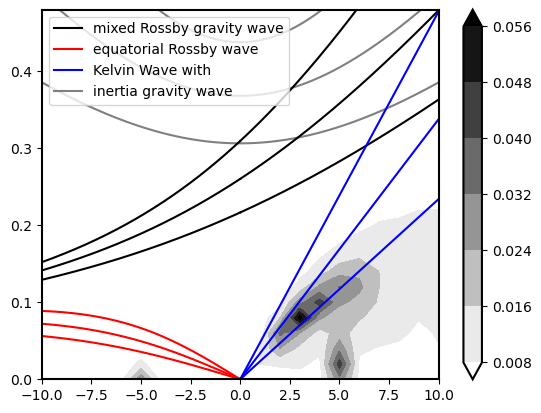

In [333]:
k_max       = 62
w_max       = 24

wave_number = np.arange(-k_max,k_max+1,1)
frequency   = np.arange(0,w_max,1)
k,w         = np.meshgrid(wave_number,frequency)

P_total = np.zeros((w_max,2*k_max+1))
P_total[:,k_max]         = (P_T[0,0:w_max,0]+P_T[1,0:w_max,0])
P_total[:,k_max+1:]      = P_T[0,0:w_max,1:k_max+1] 
P_total[:,k_max-1::-1]   = P_T[1,0:w_max,1:k_max+1] 

plt.figure()
making_theoretical_line()
cs=plt.contourf(-k,w/50,P_total[:,:],extend='both',cmap='gray_r')

plt.colorbar(cs)
plt.xlim([-10,10])
plt.ylim([0,24/50])

## Reconstruct the time series 

pass dimension check
pass dimension check


/tmp/ipykernel_2052799/10529607.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


(-3.0, 3.0)

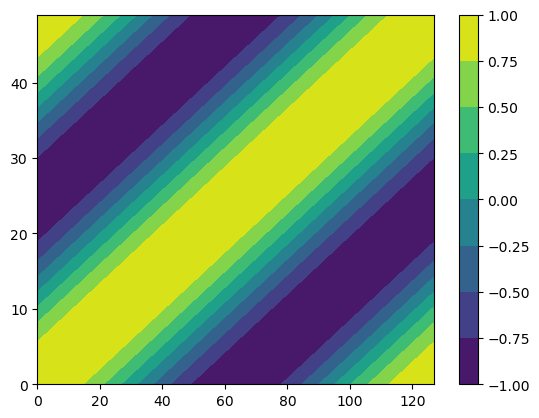

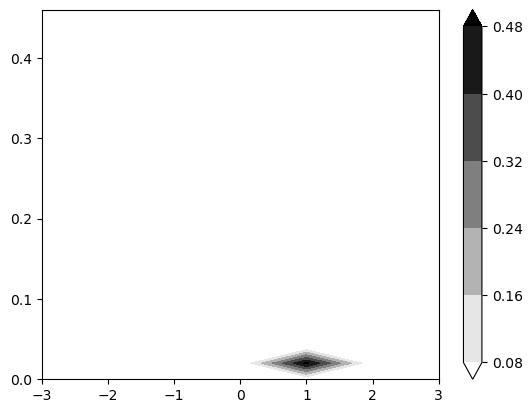

In [12]:
# Synethic Data 
x     = np.linspace(0,128,128)
t     = np.linspace(0,50,50)
xx,tt = np.meshgrid(x,t)


plt.figure()
cs=plt.contourf(np.cos(2*np.pi/128*(xx-tt/50*128)))
plt.colorbar(cs)
tmp     = np.cos(2*np.pi/128*(xx-tt/50*128))

A_kw, B_kw, a_kw, b_kw = FFT2D(tmp,dim_time,dim_lon)
P_T                    = np.zeros([2,A_kw.shape[0],A_kw.shape[1]]) # eastward/westward, wave number, frequency

count   = 0

## West component, B_kw, a_kw
## East component, A_kw, b_kw

#for i in range(dim_chunk):
for i in range(1):
    A_kw, B_kw, a_kw, b_kw   = FFT2D(tmp,dim_time,dim_lon)
    P_T[0,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[0,:,:]*count)/(count+1)
    P_T[1,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[1,:,:]*count)/(count+1)
P_total = np.zeros((w_max,2*k_max+1))
P_total[:,k_max]         = (P_T[0,0:w_max,0]+P_T[1,0:w_max,0])
P_total[:,k_max+1:]      = P_T[0,0:w_max,1:k_max+1] 
P_total[:,k_max-1::-1]   = P_T[1,0:w_max,1:k_max+1] 
plt.figure()
cs=plt.contourf(-k,w/50,P_total[:,:],extend='both',cmap='gray_r')
plt.colorbar(cs)
plt.xlim([-3,3])

(50, 5, 128) (50, 5, 128)


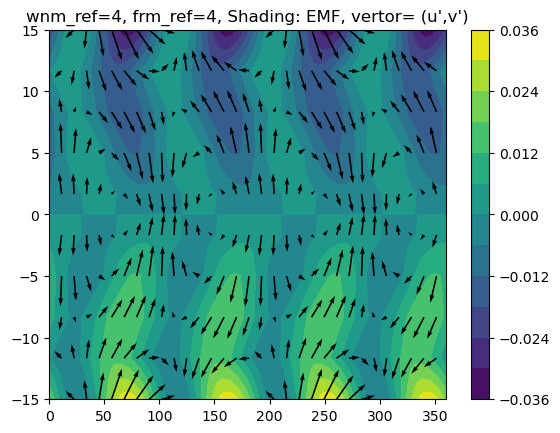

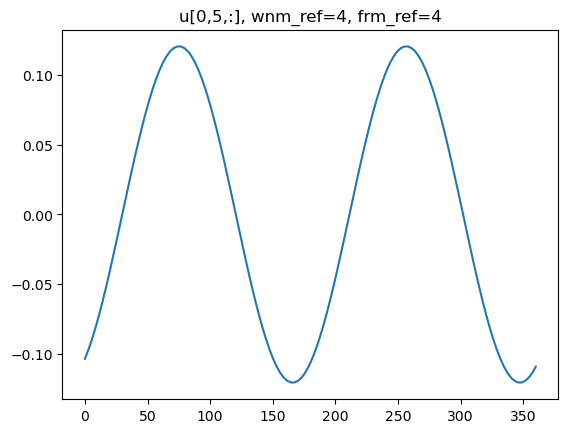

In [59]:
# Prec
tmp_s  = prec_daily_chunk[0,:,lat_cond.min():32,:][:,::-1,:]
tmp_n  = prec_daily_chunk[0,:,32:lat_cond.max()+1,:]
# OLNY for U and P !!!
# find symmetric u(time, y, x) -> then fft -> do u' (time, y, x)
# 1. tmp_mean = (tmp_n - tmp_s) /2 # (time, 1, x) 
# 2. tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
# 3. 
# tmp_filter_s = tmp_filter/2
# tmp_filter_n = tmp_filter/2

tmp_mean = (tmp_s + tmp_n) /2 

tmp_filter = space_time_recon(tmp_mean, wnm_ref=1, frm_ref=1, direction='east')
tmp_filter_s = tmp_filter/2
tmp_filter_n = tmp_filter/2 # == u'(time, (32-27), x)
"""
# 11/23 
# TODO: 1. first test wnm_ref=2,frm_ref=2 -> quiver(u', v')
# TODO: 2. for loop all over y -> u' (time, y, x)!!!
"""
##################################################################################
# u
# OLNY for U and P !!!
# find symmetric u(time, y, x) -> then fft -> do u' (time, y, x)
# 1. tmp_mean = (tmp_n - tmp_s) /2 # (time, 1, x) 
# 2. tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
# 3. 
# tmp_filter_s = tmp_filter/2
# tmp_filter_n = tmp_filter/2

u_tmp_s  = u_daily_chunk[0,:,lat_cond.min():32,:][:,::-1,:]
u_tmp_n  = u_daily_chunk[0,:,32:lat_cond.max()+1,:]
print(u_tmp_s.shape, u_tmp_n.shape)


u_tmp_mean = (u_tmp_s + u_tmp_n) /2 

u_tmp_filter = space_time_recon(u_tmp_mean, wnm_ref=2, frm_ref=2, direction='east')
u_tmp_filter_s = u_tmp_filter/2
u_tmp_filter_n = u_tmp_filter/2 # == u'(time, (32-27), x)
"""
# 11/23 
# TODO: 1. first test wnm_ref=2,frm_ref=2 -> quiver(u', v')
# TODO: 2. for loop all over y -> u' (time, y, x)!!!
"""
##################################################################################
##################################################################################
# v
# OLNY for V and vor !!!
# find symmetric v(time, y, x) -> then fft -> do v' (time, y, x)
# 1. tmp_mean = (tmp_n - tmp_s) /2 # (time, 1, x) 
# 2. tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
# 3. 
# tmp_filter_s = -tmp_filter/2
# tmp_filter_n = tmp_filter/2
v_tmp_s  = v_daily_chunk[0,:,lat_cond.min():32,:][:,::-1,:]
v_tmp_n  = v_daily_chunk[0,:,32:lat_cond.max()+1,:]

v_tmp_mean = (v_tmp_s + v_tmp_n) /2 

v_tmp_filter = space_time_recon(v_tmp_mean, wnm_ref=2, frm_ref=2, direction='east')
v_tmp_filter_s = -v_tmp_filter/2
v_tmp_filter_n = v_tmp_filter/2 # == v'(time, (32-27), x)


EMF_s = u_tmp_filter_s * v_tmp_filter_s
EMF_n = u_tmp_filter_n * v_tmp_filter_n
# print(EMF_s.shape)
EMF_global          = np.append(EMF_s[:,::-1], EMF_n, axis=1)
u_tmp_filter_global = np.append(u_tmp_filter_s[:,::-1], u_tmp_filter_n, axis=1)
v_tmp_filter_global = np.append(v_tmp_filter_s[:,::-1], v_tmp_filter_n, axis=1)

x = np.linspace(0,360,128)
y = np.linspace(-15,15,10)
xx, yy = np.meshgrid(x,y)
plt.figure()
idx = 1
idy = 4

cs=plt.contourf(xx, yy, EMF_global[0], levels=11)
# plt.quiver(xx[::idx, ::idy], yy[::idx, ::idy], u_normalized, v_normalized, 
#            color="black", scale_units='xy', angles='xy', width=4e-3, scale=250E-3)
plt.quiver(xx[::idx, ::idy], yy[::idx, ::idy], u_tmp_filter_global[0][::idx, ::idy], v_tmp_filter_global[0][::idx, ::idy]
           ,color="black", scale_units='xy', angles='xy', width=4e-3, scale=32E-3)
# cs=plt.contour(np.squeeze(tmp_filter))
plt.colorbar(cs)
plt.title("wnm_ref=4, frm_ref=4, Shading: EMF, vertor= (u',v')")


plt.figure()
plt.title("u[0,5,:], wnm_ref=4, frm_ref=4")
plt.plot(x, u_tmp_filter_global[0,5,:])

## u and v (19500, y, x)


## Select (wnm_ref=1-5), (frm_ref=1-10), and (west and east)
##
## Take wnm_ref=1, frm_ref=1, and west, for example:
## 
## 
<!-- ## length_for_u_prime = np.zeros((19500-50+1, y, x) -->
## final_m_all = np.zeros(19500-50+1)

## aa = 0
## u_window = np.zeros((50, y, x))
## Do for loop for i in range(25,19500-25+1):
###     Step.0 Split u in u_window (50, y, x):
###            u_window[:,y,x] = u[i-25:i+25,y,x] 
###     Step.1 got u'_window[50,:,:] (time, y, x) and v'_window[50,:,:] (time, y, x)
###     Step.2 do zonal mean got $\overline{u^{'}v^{'}}$ (time, y)
###     Step.3 dot -d$\overline{u'v'}$/dy (time, y) on EOF(y) got m(time) = m(50)
###     Step.4 final_m_all[aa:aa+50] = m(50)
###     aa += 50
## So I will have m_all (779, 50) => then ...??? mean it ???

In [298]:
print(u_daily.shape)
v_daily.shape
time_dim, y_dim, x_dim = prec_daily.shape
print(prec_daily.shape)


(19500, 64, 128)
(19500, 64, 128)


In [334]:
lat              = np.linspace(-90, 90, 64)
lat_cond         = np.where((lat>=-30)&(lat<=30))[0]

In [335]:
# Initialize arrays for results
prec_tmp_filter_s = np.zeros_like(prec_daily[25:-25, lat_cond.min():32, :])
prec_tmp_filter_n = np.zeros_like(prec_daily[25:-25, 32:lat_cond.max() + 1, :])
print(prec_tmp_filter_s.shape)
# Iterate over the central days for the sliding window
for i in range(25, prec_daily.shape[0] - 25):
    if i <= 19425:
        # break
        # Extract a 50-day window centered around the current day
        prec_daily_window = prec_daily[(i - 25):(i + 25), :, :]
    
        # Northern and southern regions
        tmp_s = prec_daily_window[:, lat_cond.min():32, :][:, ::-1, :]
        tmp_n = prec_daily_window[:, 32:lat_cond.max() + 1, :]
    
        # Compute symmetric mean
        tmp_mean = (tmp_s + tmp_n) / 2
    
        # Apply spatial-temporal filtering
        tmp_filter = space_time_recon(tmp_mean, wnm_ref=1, frm_ref=1, direction="east")
        # Assign filtered results
        prec_tmp_filter_s[(i - 25): (i+25)] = tmp_filter[:, :, :] / 2  # Southern region
        prec_tmp_filter_n[(i - 25): (i+25)] = tmp_filter[:, :, :] / 2  # Northern region

# Verify the shape of the results
print("Shape of prec_tmp_filter_s:", prec_tmp_filter_s.shape)
print("Shape of prec_tmp_filter_n:", prec_tmp_filter_n.shape)
##################################################################################
# u
u_tmp_filter_s = np.zeros_like(u_daily[25:-25, lat_cond.min():32, :])
u_tmp_filter_n = np.zeros_like(u_daily[25:-25, 32:lat_cond.max() + 1, :])

# Iterate over the central days for the sliding window
for i in range(25, u_daily.shape[0] - 25):
    if i <= 19425:
        # Extract a 50-day window centered around the current day
        u_daily_window = u_daily[(i - 25):(i + 25), :, :]
    
        # Northern and southern regions
        tmp_s = u_daily_window[:, lat_cond.min():32, :][:, ::-1, :]
        tmp_n = u_daily_window[:, 32:lat_cond.max() + 1, :]
    
        # Compute symmetric mean
        tmp_mean = (tmp_s + tmp_n) / 2
    
        # Apply spatial-temporal filtering
        tmp_filter = space_time_recon(tmp_mean, wnm_ref=1, frm_ref=1, direction="east")
    
        # Assign filtered results
        u_tmp_filter_s[i - 25:i+25] = tmp_filter[:, :, :] / 2  # Southern region
        u_tmp_filter_n[i - 25:i+25] = tmp_filter[:, :, :] / 2  # Northern region

# Verify the shape of the results
print("Shape of prec_tmp_filter_s:", prec_tmp_filter_s.shape)
print("Shape of prec_tmp_filter_n:", prec_tmp_filter_n.shape)

##################################################################################
# v
v_tmp_filter_s = np.zeros_like(v_daily[25:-25, lat_cond.min():32, :])
v_tmp_filter_n = np.zeros_like(v_daily[25:-25, 32:lat_cond.max() + 1, :])

# Iterate over the central days for the sliding window
for i in range(25, v_daily.shape[0] - 25):
    if i <= 19425:
        # Extract a 50-day window centered around the current day
        v_daily_window = v_daily[(i - 25):(i + 25), :, :]
    
        # Northern and southern regions
        tmp_s = v_daily_window[:, lat_cond.min():32, :][:, ::-1, :]
        tmp_n = v_daily_window[:, 32:lat_cond.max() + 1, :]
    
        # Compute symmetric mean
        tmp_mean = (tmp_s + tmp_n) / 2
    
        # Apply spatial-temporal filtering
        tmp_filter = space_time_recon(tmp_mean, wnm_ref=1, frm_ref=1, direction="east")
    
        # Assign filtered results
        v_tmp_filter_s[i - 25:i+25] = -tmp_filter[:, :, :] / 2  # Southern region
        v_tmp_filter_n[i - 25:i+25] = tmp_filter[:, :, :] / 2  # Northern region

# Verify the shape of the results
print("Shape of prec_tmp_filter_s:", prec_tmp_filter_s.shape)
print("Shape of prec_tmp_filter_n:", prec_tmp_filter_n.shape)
##################################################################################


(19450, 11, 128)
Shape of prec_tmp_filter_s: (19450, 11, 128)
Shape of prec_tmp_filter_n: (19450, 11, 128)
Shape of prec_tmp_filter_s: (19450, 11, 128)
Shape of prec_tmp_filter_n: (19450, 11, 128)
Shape of prec_tmp_filter_s: (19450, 11, 128)
Shape of prec_tmp_filter_n: (19450, 11, 128)


In [336]:
u_daily.shape

(19500, 64, 128)

In [337]:
prec_tmp_filter_n.shape

(19450, 11, 128)

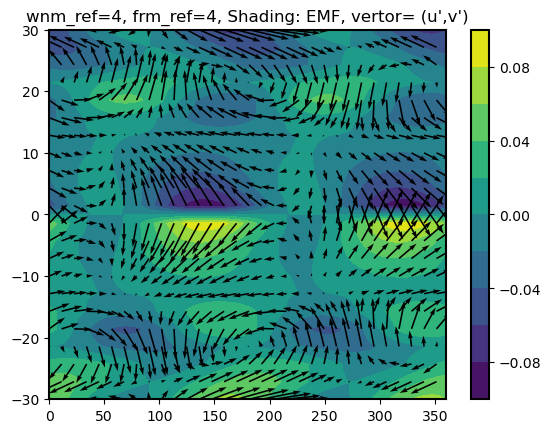

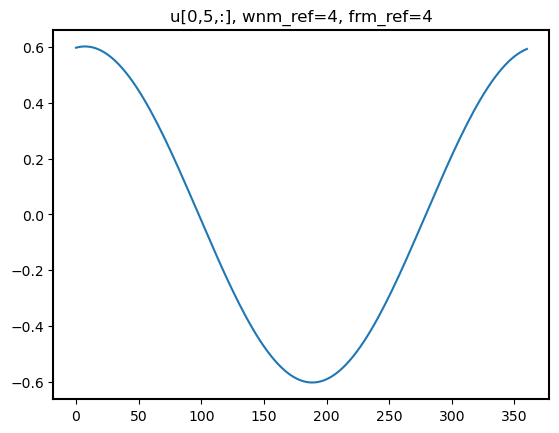

In [338]:
EMF_s = u_tmp_filter_s * v_tmp_filter_s
EMF_n = u_tmp_filter_n * v_tmp_filter_n
# print(EMF_s.shape)
EMF_global          = np.append(EMF_s[:,::-1], EMF_n, axis=1)
u_tmp_filter_global = np.append(u_tmp_filter_s[:,::-1], u_tmp_filter_n, axis=1)
v_tmp_filter_global = np.append(v_tmp_filter_s[:,::-1], v_tmp_filter_n, axis=1)

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx, yy = np.meshgrid(x,y[lat_cond])
plt.figure()
idx = 1
idy = 4

cs=plt.contourf(xx, yy, EMF_global[0], levels=11)
# plt.quiver(xx[::idx, ::idy], yy[::idx, ::idy], u_normalized, v_normalized, 
#            color="black", scale_units='xy', angles='xy', width=4e-3, scale=250E-3)
plt.quiver(xx[::idx, ::idy], yy[::idx, ::idy], u_tmp_filter_global[0][::idx, ::idy], v_tmp_filter_global[0][::idx, ::idy]
           ,color="black", scale_units='xy', angles='xy', width=4e-3, scale=32E-3)
# cs=plt.contour(np.squeeze(tmp_filter))
plt.colorbar(cs)
plt.title("wnm_ref=4, frm_ref=4, Shading: EMF, vertor= (u',v')")


plt.figure()
plt.title("u[0,5,:], wnm_ref=4, frm_ref=4")
plt.plot(x, u_tmp_filter_global[0,5,:])

In [339]:
y_tropic = y[lat_cond]
yd_tropic = np.deg2rad(y_tropic)
cy_tropic = np.cos(yd_tropic) 

print(y_tropic)


[-30.         -27.14285714 -24.28571429 -21.42857143 -18.57142857
 -15.71428571 -12.85714286 -10.          -7.14285714  -4.28571429
  -1.42857143   1.42857143   4.28571429   7.14285714  10.
  12.85714286  15.71428571  18.57142857  21.42857143  24.28571429
  27.14285714  30.        ]


In [408]:
lat_size = np.shape(lat_cond)[0]
dmdy = np.zeros((19450, lat_size))
print(u_tmp_filter_global.shape)
Mzm = np.mean(u_tmp_filter_global[:] * v_tmp_filter_global[:], axis=2) # EMF_oringin_grid[a]

for i in range(1,lat_size-1):
    dmdy[:,i] = -(Mzm[:,i+1] * (cy_tropic[i]**2) - Mzm[:,i-1]* (cy_tropic[i]**2)) / (radius * (cy_tropic[i]**2) * (yd_tropic[i+1] - yd_tropic[i-1]))

dmdy[:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy_tropic[0]**2)  / (radius* cy_tropic[0]**2  *(yd_tropic[1] - yd_tropic[0]))
dmdy[:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy_tropic[-1]**2) / (radius* cy_tropic[-1]**2 *(yd_tropic[-1] - yd_tropic[-2]))
print(dmdy.shape)

(19450, 22, 128)
(19450, 22)


In [410]:
import numpy as np

# Define your inputs
lat_size = Mzm.shape[1]  # Assuming Mzm has dimensions (time, latitude)
radius = 6.37122e6  # Earth's radius in meters
cy_tropic = np.cos(yd_tropic)  # Cosine of latitudes
cy2_tropic = cy_tropic ** 2  # Square of cosine of latitudes

# Latitude spacing (assumed uniform here)
delta_y = np.diff(yd_tropic)  # Differences between adjacent latitudes (radians)

# Initialize the differentiation matrix
D = np.zeros((lat_size, lat_size))

# Fill the central difference part of the matrix
for i in range(1, lat_size - 1):
    D[i, i - 1] = -cy2_tropic[i] / (cy2_tropic[i] * (delta_y[i - 1] + delta_y[i]))
    D[i, i + 1] = cy2_tropic[i] / (cy2_tropic[i] * (delta_y[i - 1] + delta_y[i]))

# Fill the boundary points with forward and backward difference formulas
D[0, 0] = -1 / (delta_y[0])  # Backward difference at the first point
D[0, 1] = 1 / (delta_y[0])   # Forward difference at the first point

D[-1, -2] = -1 / (delta_y[-1])  # Backward difference at the last point
D[-1, -1] = 1 / (delta_y[-1])   # Forward difference at the last point

# Scale the differentiation matrix with the Earth's radius
D = D / radius

# Apply the differentiation matrix to Mzm
dmdy = -Mzm @ D.T  # Transpose because differentiation is row-wise

print("dmdy shape:", dmdy.shape)


dmdy shape: (19450, 22)


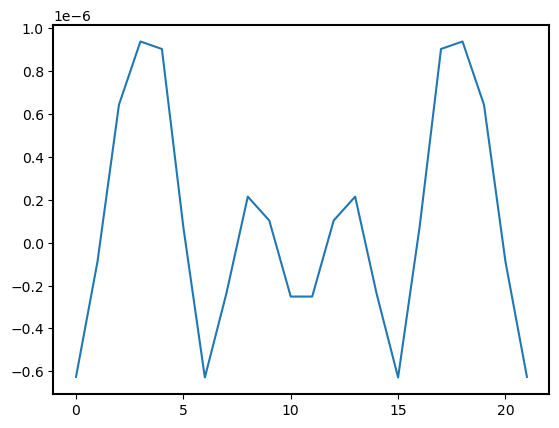

In [411]:
plt.figure()
plt.plot(dmdy.mean(axis=0))

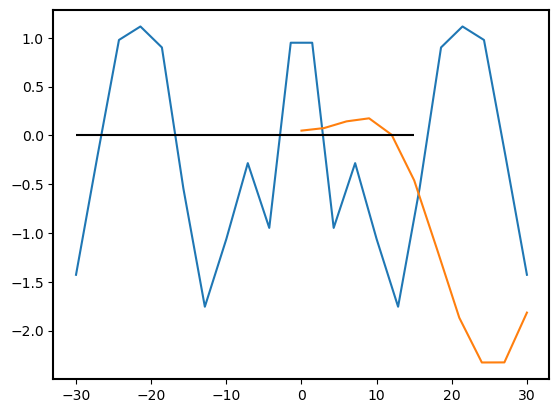

In [412]:
day_sel = 300
exp_sel = 0   # PR

plt.figure()
plt.plot(y_tropic, dmdy[day_sel]/dmdy[day_sel].std() )
# plt.plot(np.linspace(0,y_tropic[-1],5), EOF1_all[0,:5]/EOF1_all[0,:5].std())
plt.plot(np.linspace(0,y_tropic[-1],int(lat_size/2)), EOF1_all[exp_sel,:int(lat_size/2)]/EOF1_all[exp_sel,:int(lat_size/2)].std())

plt.hlines(y=0, xmin=y_tropic[0], xmax=15, color="Black")

(6, 32)


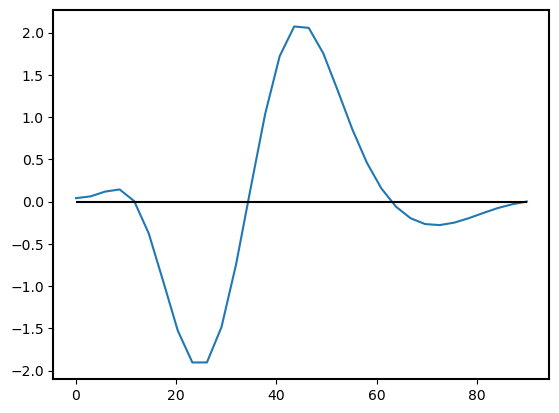

In [413]:
plt.figure()
plt.plot(np.linspace(0,90,32), EOF1_all[exp_sel]/EOF1_all[exp_sel].std() )
plt.hlines(y=0, xmin=0, xmax=90, color="Black")

print(EOF1_all.shape)

In [414]:
print(lat_size)
EOF1_dry = EOF1_all[exp_sel,0:int(lat_size/2)]

contribution = np.dot(dmdy[day_sel,int(lat_size/2):], EOF1_dry)
print(contribution)


22
-1.7108843507608912e-06


In [267]:
EOF1_dry.shape

(5,)

## Take PC1 time index > and < std  

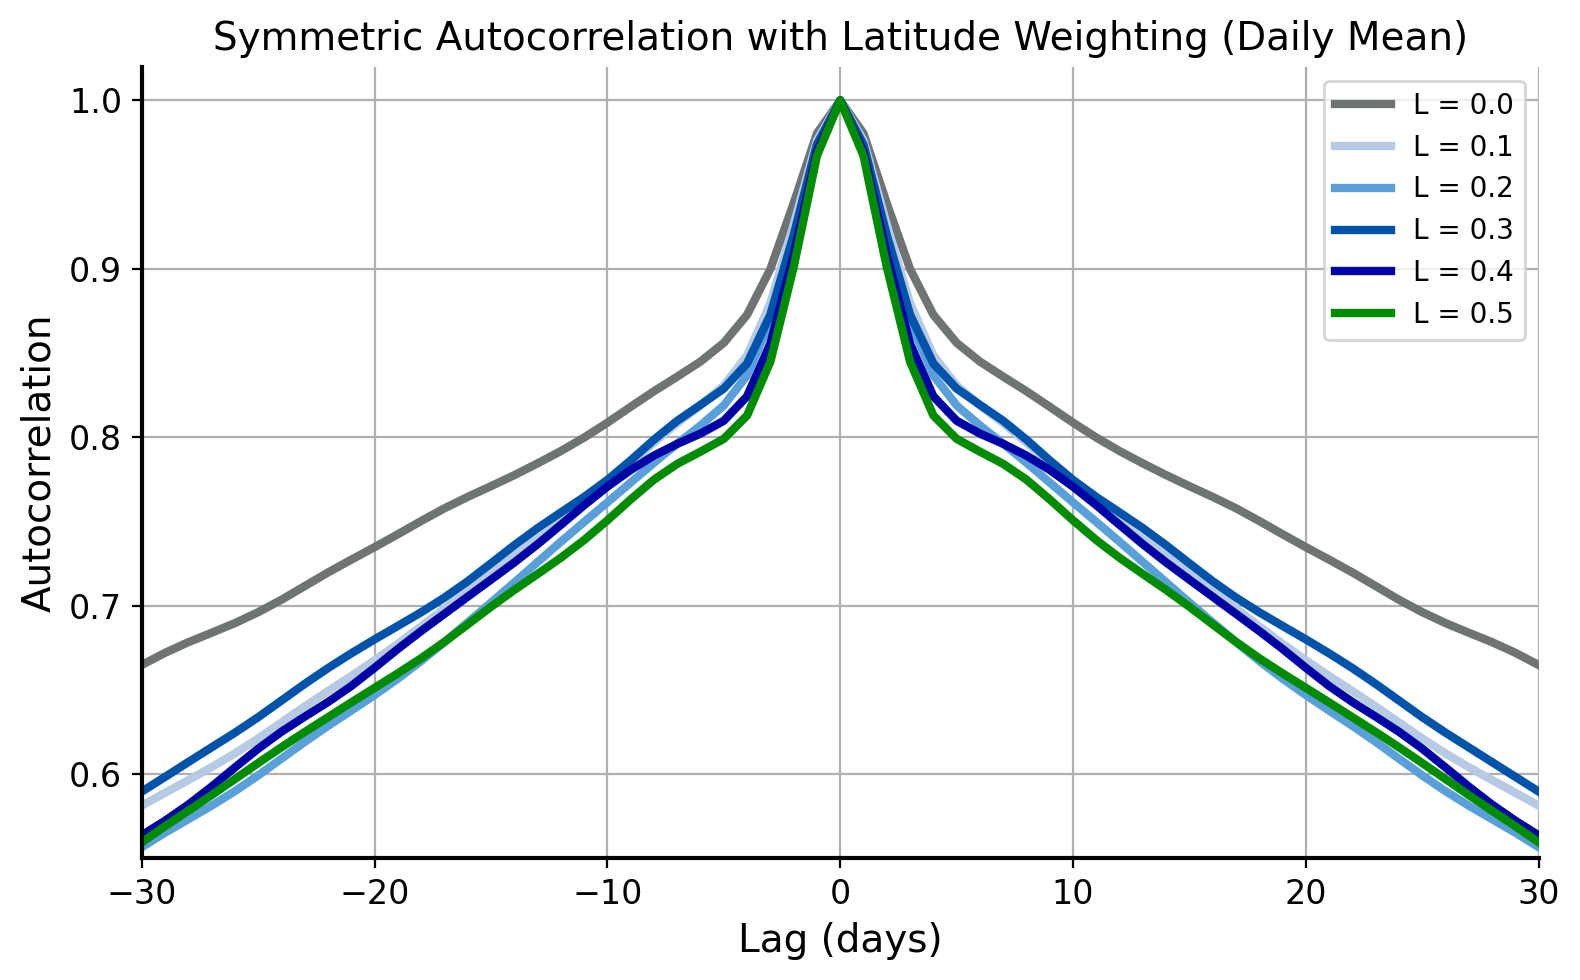

In [369]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)

        return EOF_modes, PCs_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)


# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
auto_length = 100
window_length = 500
split_to_chunk = False
latitudes = np.linspace(0, 90, 32)

# Load data, calculate daily mean, and compute PC1 for all PR values
PC1_all  = []
EOFs_all = []


for PR in PR_values:
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    variable_name = "u"
    u_data = moist_dycore.load_data(file_path, variable_name)
    
    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)

    # Use the custom EOF class
    EOFs, PC_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[:, 32:], latitudes, n_components=32, field="1D")
    EOFs_all.append(EOFs[:])  # Extract normalized PC1 for the current PR value
    PC1_all.append(PC_normalized[:])  # Extract normalized PC1 for the current PR value
    

PC1_all  = np.array(PC1_all)
EOFs_all = np.array(EOFs_all)


# Calculate symmetric autocorrelation for PC1
autocorr_results = []
for i in range(len(PR_values)):
    autocorr_results.append(
        moist_dycore.symmetric_autocorr(PC1_all[i, :], auto_length, split_to_chunk, window_length)
    )

# tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [195]:
EMF = np.zeros((6, 19500, 64))
aa = 0
for PR in range(0, 60, 10):
    # if PR == 40:
    #     pass
    # else:
        EMF_file = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/EMF_add_time_dim/EMF_climatology_add_time_dim.h5"
        with h5py.File(EMF_file,'r') as f :
            EMF[aa] = f["EMF"][:,:].reshape(19500,4,64).mean(axis=1)
        aa += 1

In [196]:
time_idx_positive = np.zeros(19500)
time_idx_negative = np.zeros(19500)

radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy **2

sigma_onlyz = np.linspace(0,1,20)
yy, sigma_mean2 = np.meshgrid(y, sigma_onlyz)

dmdy = np.zeros((6, 19500, 64))
for a in range(6):
    Mzm = EMF[a] # EMF_oringin_grid[a]
    print(Mzm.shape)
    
    for i in range(1,64-1):
        dmdy[a,:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    # dmdy[a,:,:,1:-1] = -((Mzm[:,:,2:] - Mzm[:,:,:-2]) * cy2[1:-1]) / (radius * (cy2[1:-1]) * (yd[2:] - yd[:-2]))
    
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))
print(dmdy.shape)

(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(6, 19500, 64)


In [199]:
EOF1_all = EOFs_all[:,0,:]
print(EOF1_all.shape)

m_all = np.zeros((6, 19500))
for i in range(6):
    m_all[i] = dmdy[i,:,32:].dot(EOF1_all[i,:])


(6, 32)


(3069,) (3041,)


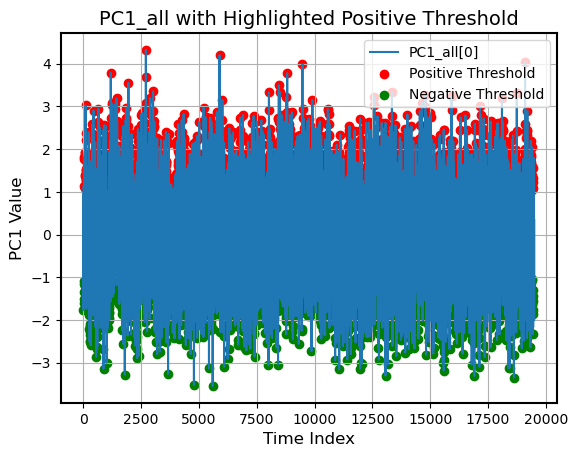

In [204]:
m_all_normalize = np.zeros_like(m_all)
for i in range(6):
    m_all_normalize[i] = (m_all[i] - m_all[i].mean()) / m_all[i].std()
# Initialize arrays for indices
i = 0

time_idx_positive = np.where(m_all_normalize[i] > m_all_normalize[i].std())[0]  # Indices where PC1_all[i] > standard deviation
time_idx_negative = np.where(m_all_normalize[i] < -m_all_normalize[i].std())[0]  # Indices where PC1_all[i] > standard deviation
print(time_idx_positive.shape, time_idx_negative.shape)

time_idx_positive = time_idx_positive[time_idx_positive <19450]
time_idx_negative = time_idx_negative[time_idx_negative <19450]


# Plot PC1_all
plt.figure()
plt.plot(m_all_normalize[i], label="PC1_all[0]")
plt.scatter(time_idx_positive, m_all_normalize[i][time_idx_positive], color='red', label="Positive Threshold")
plt.scatter(time_idx_negative, m_all_normalize[i][time_idx_negative], color='green', label="Negative Threshold")


# Customize plot
plt.title("PC1_all with Highlighted Positive Threshold", fontsize=14)
plt.xlabel("Time Index", fontsize=12)
plt.ylabel("PC1 Value", fontsize=12)
plt.legend()
plt.grid()
plt.show()


Text(0.5, 1.0, "wnm_ref=4, frm_ref=4, Shading: EMF, vertor= (u',v')")

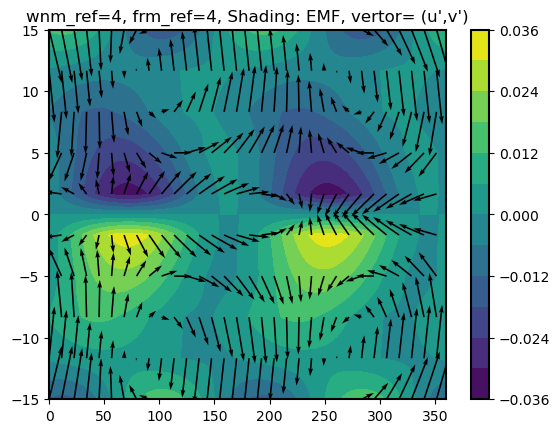

In [227]:

plt.figure()
idx = 1
idy = 4
x = np.linspace(0,360,128)
y = np.linspace(-15,15,10)
xx, yy = np.meshgrid(x,y)

cs=plt.contourf(xx, yy, EMF_global[time_idx_positive][0], levels=11)

plt.quiver(xx[::idx, ::idy], yy[::idx, ::idy], u_prime_positive_final[0][::idx, ::idy], v_prime_positive_final[0][::idx, ::idy]
           ,color="black", scale_units='xy', angles='xy', width=4e-3, scale=32E-3)
# cs=plt.contour(np.squeeze(tmp_filter))
plt.colorbar(cs)
plt.title("wnm_ref=4, frm_ref=4, Shading: EMF, vertor= (u',v')")

## Ccalculate Cross-spectrum 